# Data Processing Pipeline: Fill Missing Values → Cap Outliers

This notebook demonstrates the complete data preprocessing pipeline:
1. **Fill missing values** using correlation and temporal interpolation
2. **Cap outliers** using 3-stage rolling Z-score method

We'll test on feeder E5 and visualize the results at each stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Add modules to path
sys.path.append('../missing')
sys.path.append('.')

from missing import fill_missing
from outliers import cap_outliers

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_raw = pd.read_csv(consumption_path)

print(f"Loaded {len(df_raw)} records")
print(f"Missing values: {df_raw['consumption'].isna().sum()}")
print(f"Feeders: {df_raw['feeder'].nunique()}")

Loaded 1899312 records
Missing values: 50365
Feeders: 55


## Initial Correlation Matrix (Before Pipeline)

Let's visualize the correlation structure between feeders before any processing.

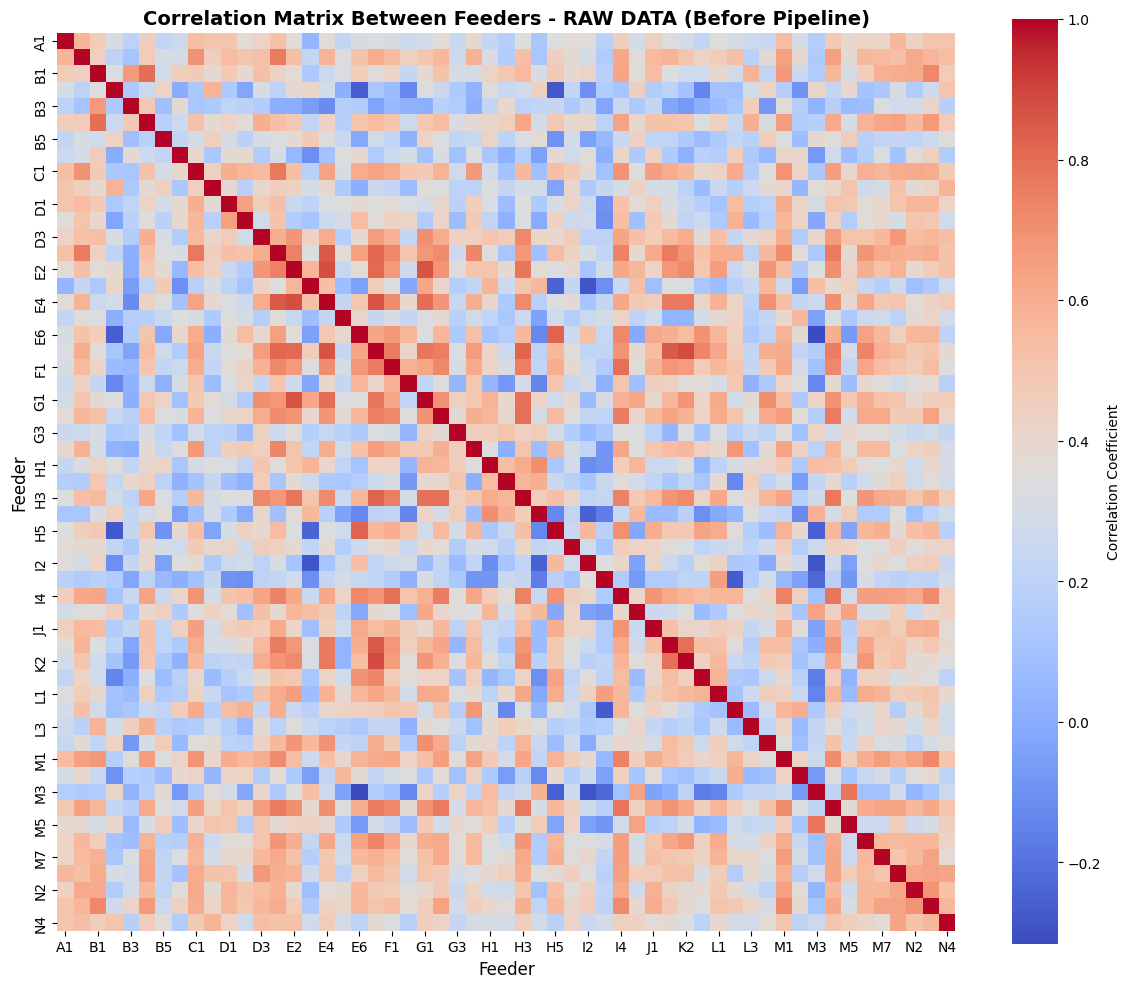

Average correlation (excluding diagonal): 0.362


In [2]:
# Create correlation matrix for raw data
pivot_df_raw = df_raw.pivot_table(index='datetime', columns='feeder', values='consumption')

# Compute the correlation matrix between feeders
corr_matrix_raw = pivot_df_raw.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_raw, annot=False, cmap='coolwarm', fmt='.2f', square=True, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix Between Feeders - RAW DATA (Before Pipeline)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feeder', fontsize=12)
plt.ylabel('Feeder', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Average correlation (excluding diagonal): {corr_matrix_raw.values[~np.eye(corr_matrix_raw.shape[0], dtype=bool)].mean():.3f}")

## Aggregated Consumption Analysis (Before Pipeline)

Let's look at the overall consumption patterns across all feeders using mean and sum aggregations.

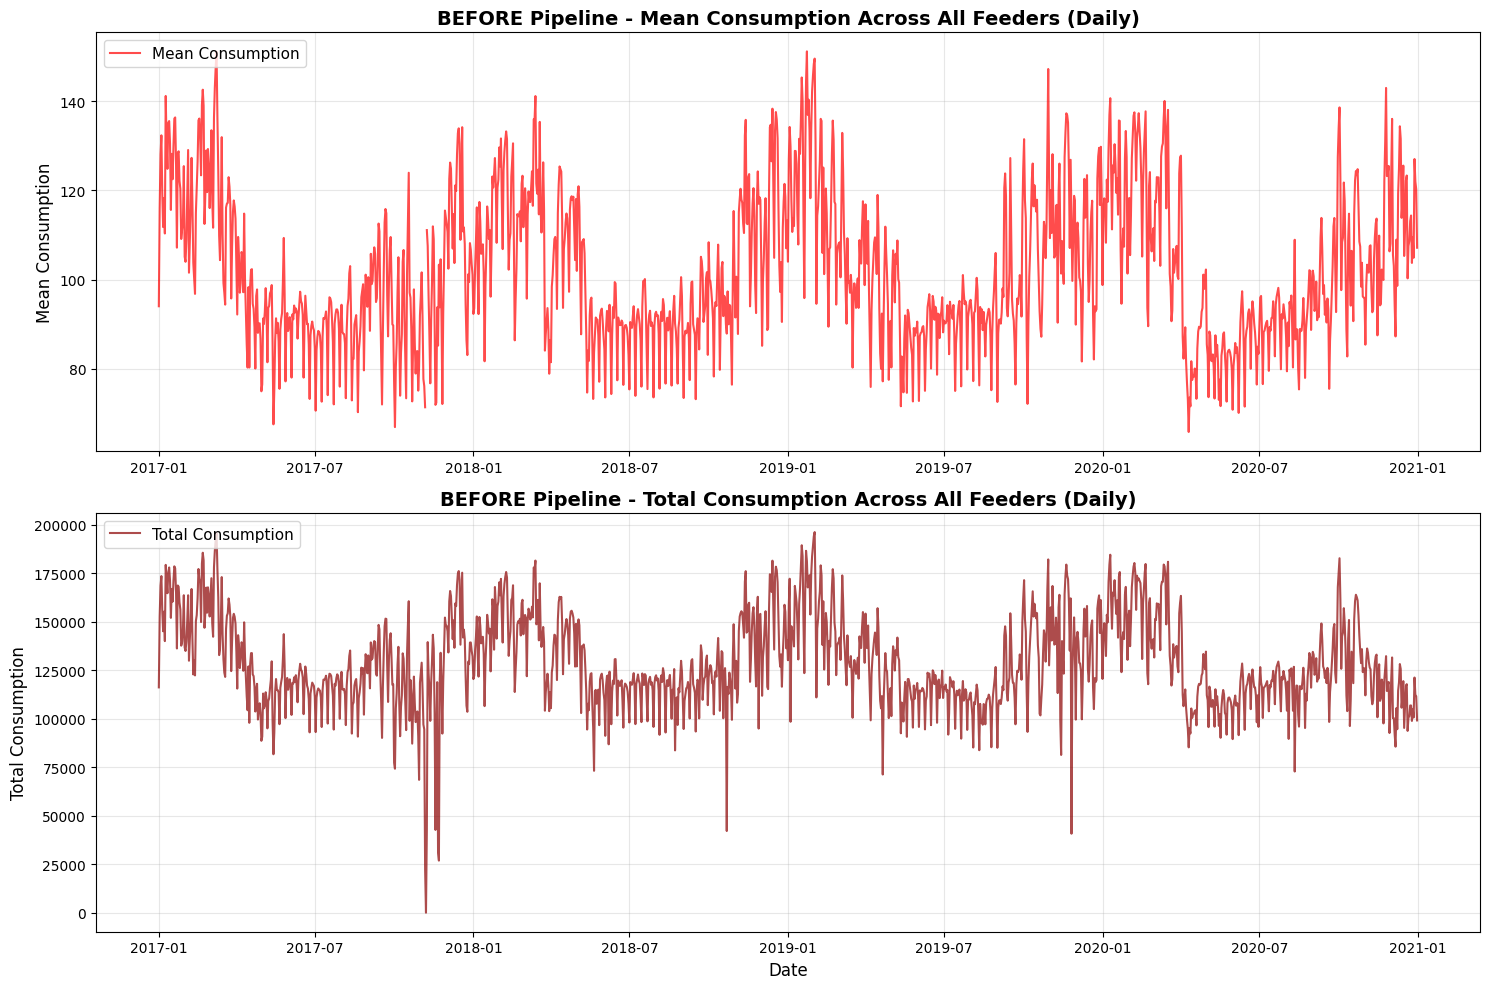

Raw Data Statistics (Aggregated):
  Mean consumption (avg across all feeders): 101.80
  Total consumption (sum across all feeders): 5403.23
  Missing timestamps: 0


In [3]:
# Calculate aggregated consumption before pipeline
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])

# Pivot to wide format for aggregation
pivot_raw = df_raw.pivot_table(index='datetime', columns='feeder', values='consumption')
pivot_raw_sorted = pivot_raw.sort_index()

# Calculate mean and sum across all feeders at each timestamp
mean_consumption_raw = pivot_raw_sorted.mean(axis=1)
sum_consumption_raw = pivot_raw_sorted.sum(axis=1)

# Resample to daily for cleaner visualization
mean_consumption_raw_daily = mean_consumption_raw.resample('D').mean()
sum_consumption_raw_daily = sum_consumption_raw.resample('D').sum()

# Plot aggregated consumption
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Mean consumption across all feeders
axes[0].plot(mean_consumption_raw_daily.index, mean_consumption_raw_daily.values,
             color='red', linewidth=1.5, alpha=0.7, label='Mean Consumption')
axes[0].set_title('BEFORE Pipeline - Mean Consumption Across All Feeders (Daily)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mean Consumption', fontsize=12)
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Sum consumption across all feeders
axes[1].plot(sum_consumption_raw_daily.index, sum_consumption_raw_daily.values,
             color='darkred', linewidth=1.5, alpha=0.7, label='Total Consumption')
axes[1].set_title('BEFORE Pipeline - Total Consumption Across All Feeders (Daily)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Total Consumption', fontsize=12)
axes[1].legend(loc='upper left', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Raw Data Statistics (Aggregated):")
print(f"  Mean consumption (avg across all feeders): {mean_consumption_raw.mean():.2f}")
print(f"  Total consumption (sum across all feeders): {sum_consumption_raw.mean():.2f}")
print(f"  Missing timestamps: {pivot_raw_sorted.isna().all(axis=1).sum()}")

## Step 1: Fill Missing Values

In [4]:
# Fill missing values
df_filled = fill_missing(df_raw)

print(f"\nAfter filling:")
print(f"Missing values: {df_filled['consumption'].isna().sum()}")

Detected data frequency: 0 days 01:00:00
Original time range: 2017-01-01 01:00:00 to 2020-12-31 23:00:00
Original timestamps: 34863
Complete time series timestamps: 35063
Missing timestamps added: 23

Found 10 highly correlated feeder pairs (correlation > 0.8)

Summary:
  Original missing values: 50365
  Missing timestamps: 29153
  Total gaps filled: 79518
  Final missing values: 1000
  Data completeness: 100.0%

After filling:
Missing values: 1000


## Step 2: Cap Outliers

In [5]:
# Cap outliers using 3-stage approach
df_capped = cap_outliers(df_filled)

Processing 55 feeders with 3-stage outlier capping...
A1: Stage1=363, Stage2=211, Stage3=111, Total=685
A2: Stage1=491, Stage2=368, Stage3=246, Total=1105
B1: Stage1=110, Stage2=5, Stage3=6, Total=121
B2: Stage1=138, Stage2=93, Stage3=96, Total=327
B3: Stage1=20, Stage2=0, Stage3=0, Total=20
B4: Stage1=120, Stage2=14, Stage3=13, Total=147
B5: Stage1=465, Stage2=348, Stage3=268, Total=1081
B6: Stage1=224, Stage2=84, Stage3=77, Total=385
C1: Stage1=375, Stage2=252, Stage3=200, Total=827
C2: Stage1=310, Stage2=179, Stage3=112, Total=601
D1: Stage1=373, Stage2=214, Stage3=119, Total=706
D2: Stage1=437, Stage2=248, Stage3=162, Total=847
D3: Stage1=280, Stage2=78, Stage3=74, Total=432
E1: Stage1=420, Stage2=273, Stage3=253, Total=946
E2: Stage1=151, Stage2=83, Stage3=61, Total=295
E3: Stage1=291, Stage2=207, Stage3=180, Total=678
E4: Stage1=301, Stage2=195, Stage3=155, Total=651
E5: Stage1=219, Stage2=155, Stage3=135, Total=509
E6: Stage1=311, Stage2=191, Stage3=153, Total=655
E7: Stage1=222

## Visualization: Compare All Stages for Feeder E5

In [32]:
# Extract E5 data at each stage
feeder = 'E6'

# Raw data
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_E5_raw = df_raw[df_raw['feeder'] == feeder].copy()
df_E5_raw = df_E5_raw.set_index('datetime').sort_index()

# Filled data
df_filled['datetime'] = pd.to_datetime(df_filled['datetime'])
df_E5_filled = df_filled[df_filled['feeder'] == feeder].copy()
df_E5_filled = df_E5_filled.set_index('datetime').sort_index()

# Capped data
df_capped['datetime'] = pd.to_datetime(df_capped['datetime'])
df_E5_capped = df_capped[df_capped['feeder'] == feeder].copy()
df_E5_capped = df_E5_capped.set_index('datetime').sort_index()

# Resample to daily averages for cleaner visualization
df_E5_raw_daily = df_E5_raw.resample('D')['consumption'].mean()
df_E5_filled_daily = df_E5_filled.resample('D')['consumption'].mean()
df_E5_capped_daily = df_E5_capped.resample('D')['consumption'].mean()

print(f"E5 Statistics:")
print(f"Raw - Missing: {df_E5_raw['consumption'].isna().sum()}, "
      f"Mean: {df_E5_raw['consumption'].mean():.2f}, "
      f"Std: {df_E5_raw['consumption'].std():.2f}")
print(f"Filled - Missing: {df_E5_filled['consumption'].isna().sum()}, "
      f"Mean: {df_E5_filled['consumption'].mean():.2f}, "
      f"Std: {df_E5_filled['consumption'].std():.2f}")
print(f"Capped - Missing: {df_E5_capped['consumption'].isna().sum()}, "
      f"Mean: {df_E5_capped['consumption'].mean():.2f}, "
      f"Std: {df_E5_capped['consumption'].std():.2f}")

E5 Statistics:
Raw - Missing: 557, Mean: 145.40, Std: 58.55
Filled - Missing: 0, Mean: 147.00, Std: 57.87
Capped - Missing: 0, Mean: 147.00, Std: 57.11


Applying mean interpolation to feeder E6 (extending to 2021-01-01)...


C:\Users\knuto\AppData\Local\Temp\ipykernel_16220\3864836073.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=feeder_data.index.min(),



Mean Interpolation Results for Feeder E6 (extended to 2021-01-01):
Date range: 2017-01-01 00:00:00 to 2021-01-01 00:00:00
Total data points: 35065
Original missing values: 557
After interpolation missing values: 42
Values filled: 515


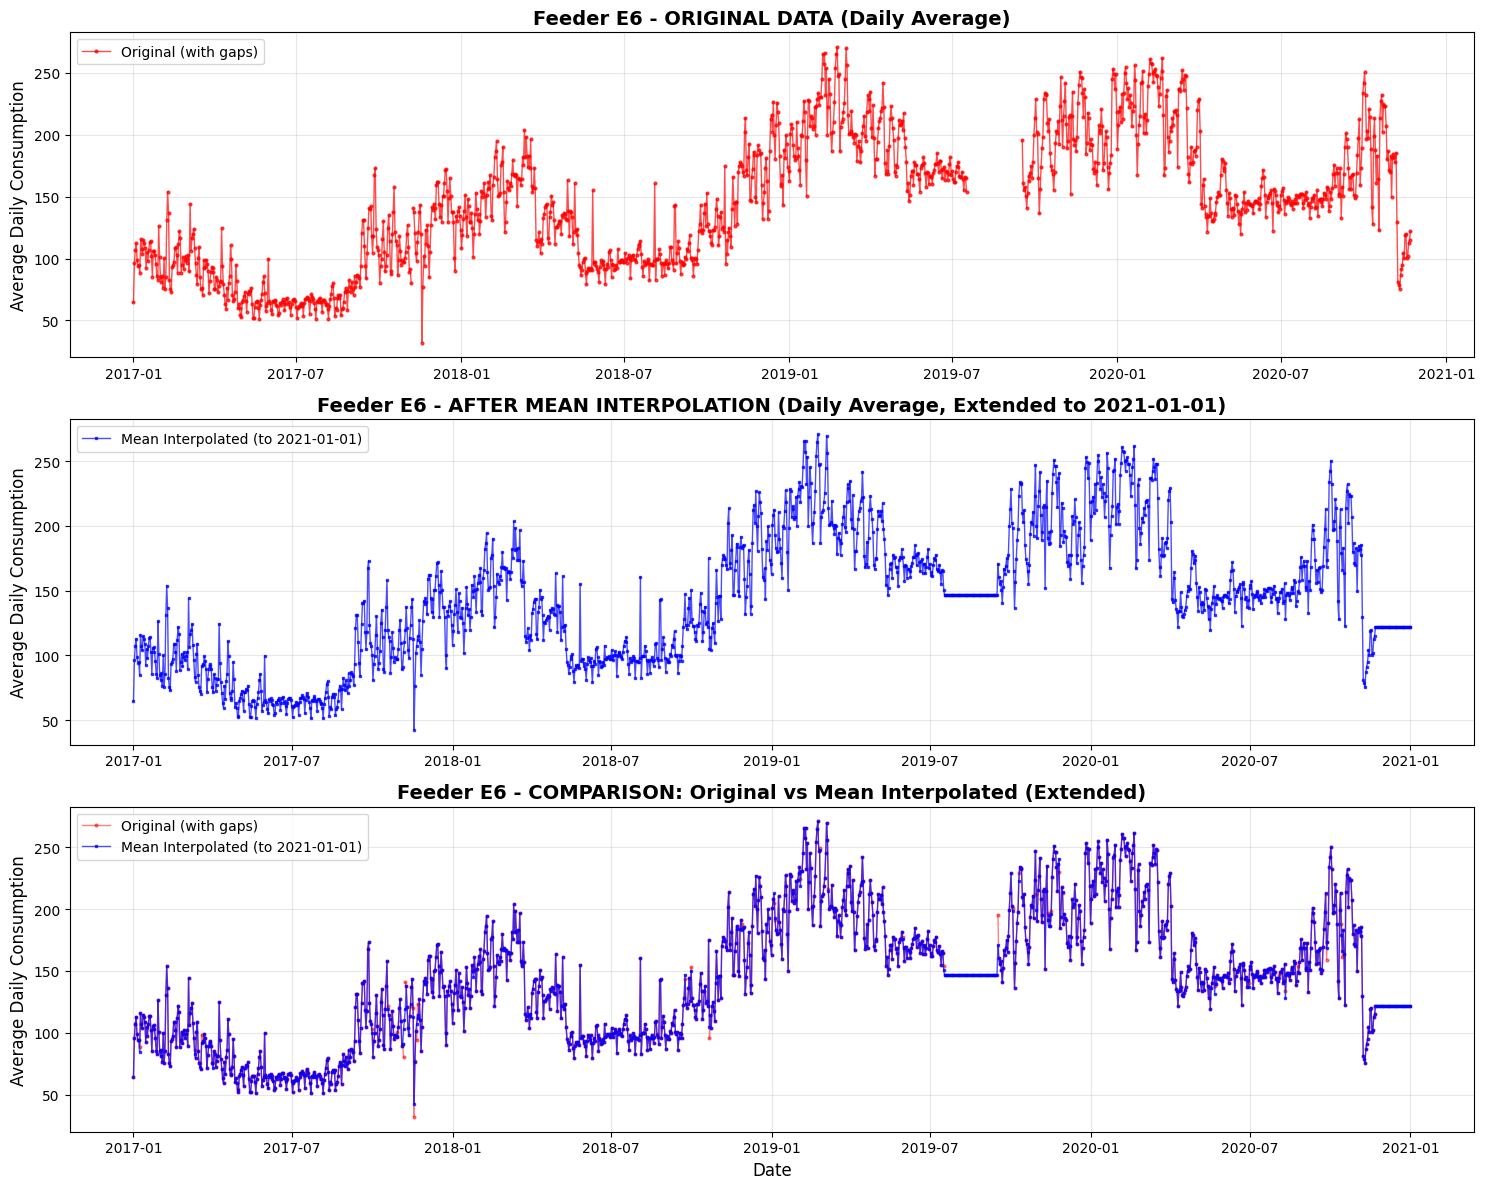


Statistical Comparison for Feeder E6 (Extended to 2021-01-01):
Metric                    Original        Mean Interp.    Change         
----------------------------------------------------------------------
Mean                      145.40          144.62          -0.78          
Std Dev                   58.55           56.55           -2.00          
Min                       9.00            9.00            +0.00          
Max                       349.00          349.00          +0.00          

✓ Mean interpolation extends data to 2021-01-01 00:00:00
✓ Gaps filled with average of last and next available points
✓ End-of-series gaps filled with last available value
✓ Total data points: 35065 (including extension)


In [38]:
def mean_interpolate_gaps(df, feeder_name, gap_threshold=1, end_date='2021-01-01'):
    """
    Perform mean interpolation for gaps larger than gap_threshold.
    For each gap > threshold, fill with the average of the last available point 
    and the next available point.
    """
    # Get feeder data
    feeder_data = df[df['feeder'] == feeder_name].copy()
    feeder_data['datetime'] = pd.to_datetime(feeder_data['datetime'])
    feeder_data = feeder_data.set_index('datetime').sort_index()
    
    # Create a complete hourly time series for this feeder extending to end_date
    full_range = pd.date_range(start=feeder_data.index.min(), 
                              end=pd.to_datetime(end_date), 
                              freq='H')
    
    # Reindex to include all timestamps
    feeder_complete = feeder_data.reindex(full_range)
    consumption = feeder_complete['consumption'].copy()
    
    # Find gaps larger than threshold
    is_null = consumption.isna()
    
    # Create groups of consecutive NaN values
    null_groups = (is_null != is_null.shift()).cumsum()
    
    # Process each group of NaN values
    for group_id in null_groups[is_null].unique():
        group_mask = (null_groups == group_id) & is_null
        gap_indices = consumption[group_mask].index
        
        if len(gap_indices) > gap_threshold:
            # Find the last available point before the gap
            before_gap_idx = None
            for i in range(len(consumption)):
                if consumption.index[i] < gap_indices[0] and not pd.isna(consumption.iloc[i]):
                    before_gap_idx = i
            
            # Find the next available point after the gap
            after_gap_idx = None
            for i in range(len(consumption)):
                if consumption.index[i] > gap_indices[-1] and not pd.isna(consumption.iloc[i]):
                    after_gap_idx = i
                    break
            
            # If we have both before and after points, interpolate
            if before_gap_idx is not None and after_gap_idx is not None:
                before_value = consumption.iloc[before_gap_idx]
                after_value = consumption.iloc[after_gap_idx]
                mean_value = (before_value + after_value) / 2
                
                # Fill the gap with the mean value
                consumption.loc[gap_indices] = mean_value
            # If we only have before point (end of series), use the last value
            elif before_gap_idx is not None:
                before_value = consumption.iloc[before_gap_idx]
                consumption.loc[gap_indices] = before_value
    
    # Create result dataframe
    result_df = pd.DataFrame({
        'datetime': consumption.index,
        'consumption': consumption.values,
        'feeder': feeder_name
    }).reset_index(drop=True)
    
    return result_df

# Apply mean interpolation to feeder E6 extending to 2021-01-01
print("Applying mean interpolation to feeder E6 (extending to 2021-01-01)...")
df_mean_interpolated = mean_interpolate_gaps(df_raw, 'E6', gap_threshold=1, end_date='2021-01-01')

# Get original data for comparison
df_E6_original = df_raw[df_raw['feeder'] == 'E6'].copy()
df_E6_original['datetime'] = pd.to_datetime(df_E6_original['datetime'])
df_E6_original = df_E6_original.set_index('datetime').sort_index()

# Set index for interpolated data
df_mean_interpolated['datetime'] = pd.to_datetime(df_mean_interpolated['datetime'])
df_mean_interpolated_indexed = df_mean_interpolated.set_index('datetime')

print(f"\nMean Interpolation Results for Feeder E6 (extended to 2021-01-01):")
print(f"Date range: {df_mean_interpolated_indexed.index.min()} to {df_mean_interpolated_indexed.index.max()}")
print(f"Total data points: {len(df_mean_interpolated_indexed)}")
print(f"Original missing values: {df_E6_original['consumption'].isna().sum()}")
print(f"After interpolation missing values: {df_mean_interpolated_indexed['consumption'].isna().sum()}")
print(f"Values filled: {df_E6_original['consumption'].isna().sum() - df_mean_interpolated_indexed['consumption'].isna().sum()}")

# Resample to daily for cleaner visualization
df_E6_original_daily = df_E6_original.resample('D')['consumption'].mean()
df_mean_interpolated_daily = df_mean_interpolated_indexed.resample('D')['consumption'].mean()

# Create visualization comparing before and after mean interpolation
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Original data with missing values
axes[0].plot(df_E6_original_daily.index, df_E6_original_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, 
             color='red', alpha=0.7, label='Original (with gaps)')
axes[0].set_title(f'Feeder E6 - ORIGINAL DATA (Daily Average)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Daily Consumption', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: After mean interpolation (now extended to 2021-01-01)
axes[1].plot(df_mean_interpolated_daily.index, df_mean_interpolated_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, 
             color='blue', alpha=0.7, label='Mean Interpolated (to 2021-01-01)')
axes[1].set_title(f'Feeder E6 - AFTER MEAN INTERPOLATION (Daily Average, Extended to 2021-01-01)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Daily Consumption', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot 3: Overlay comparison
axes[2].plot(df_E6_original_daily.index, df_E6_original_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, 
             color='red', alpha=0.5, label='Original (with gaps)')
axes[2].plot(df_mean_interpolated_daily.index, df_mean_interpolated_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, 
             color='blue', alpha=0.7, label='Mean Interpolated (to 2021-01-01)')
axes[2].set_title(f'Feeder E6 - COMPARISON: Original vs Mean Interpolated (Extended)', 
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Average Daily Consumption', fontsize=12)
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show statistics comparison
print(f"\nStatistical Comparison for Feeder E6 (Extended to 2021-01-01):")
print("=" * 70)
print(f"{'Metric':<25} {'Original':<15} {'Mean Interp.':<15} {'Change':<15}")
print("-" * 70)

orig_mean = df_E6_original['consumption'].mean()
interp_mean = df_mean_interpolated_indexed['consumption'].mean()
print(f"{'Mean':<25} {orig_mean:<15.2f} {interp_mean:<15.2f} {interp_mean - orig_mean:<+15.2f}")

orig_std = df_E6_original['consumption'].std()
interp_std = df_mean_interpolated_indexed['consumption'].std()
print(f"{'Std Dev':<25} {orig_std:<15.2f} {interp_std:<15.2f} {interp_std - orig_std:<+15.2f}")

orig_min = df_E6_original['consumption'].min()
interp_min = df_mean_interpolated_indexed['consumption'].min()
print(f"{'Min':<25} {orig_min:<15.2f} {interp_min:<15.2f} {interp_min - orig_min:<+15.2f}")

orig_max = df_E6_original['consumption'].max()
interp_max = df_mean_interpolated_indexed['consumption'].max()
print(f"{'Max':<25} {orig_max:<15.2f} {interp_max:<15.2f} {interp_max - orig_max:<+15.2f}")

print(f"\n✓ Mean interpolation extends data to 2021-01-01 00:00:00")
print(f"✓ Gaps filled with average of last and next available points")
print(f"✓ End-of-series gaps filled with last available value")
print(f"✓ Total data points: {len(df_mean_interpolated_indexed)} (including extension)")

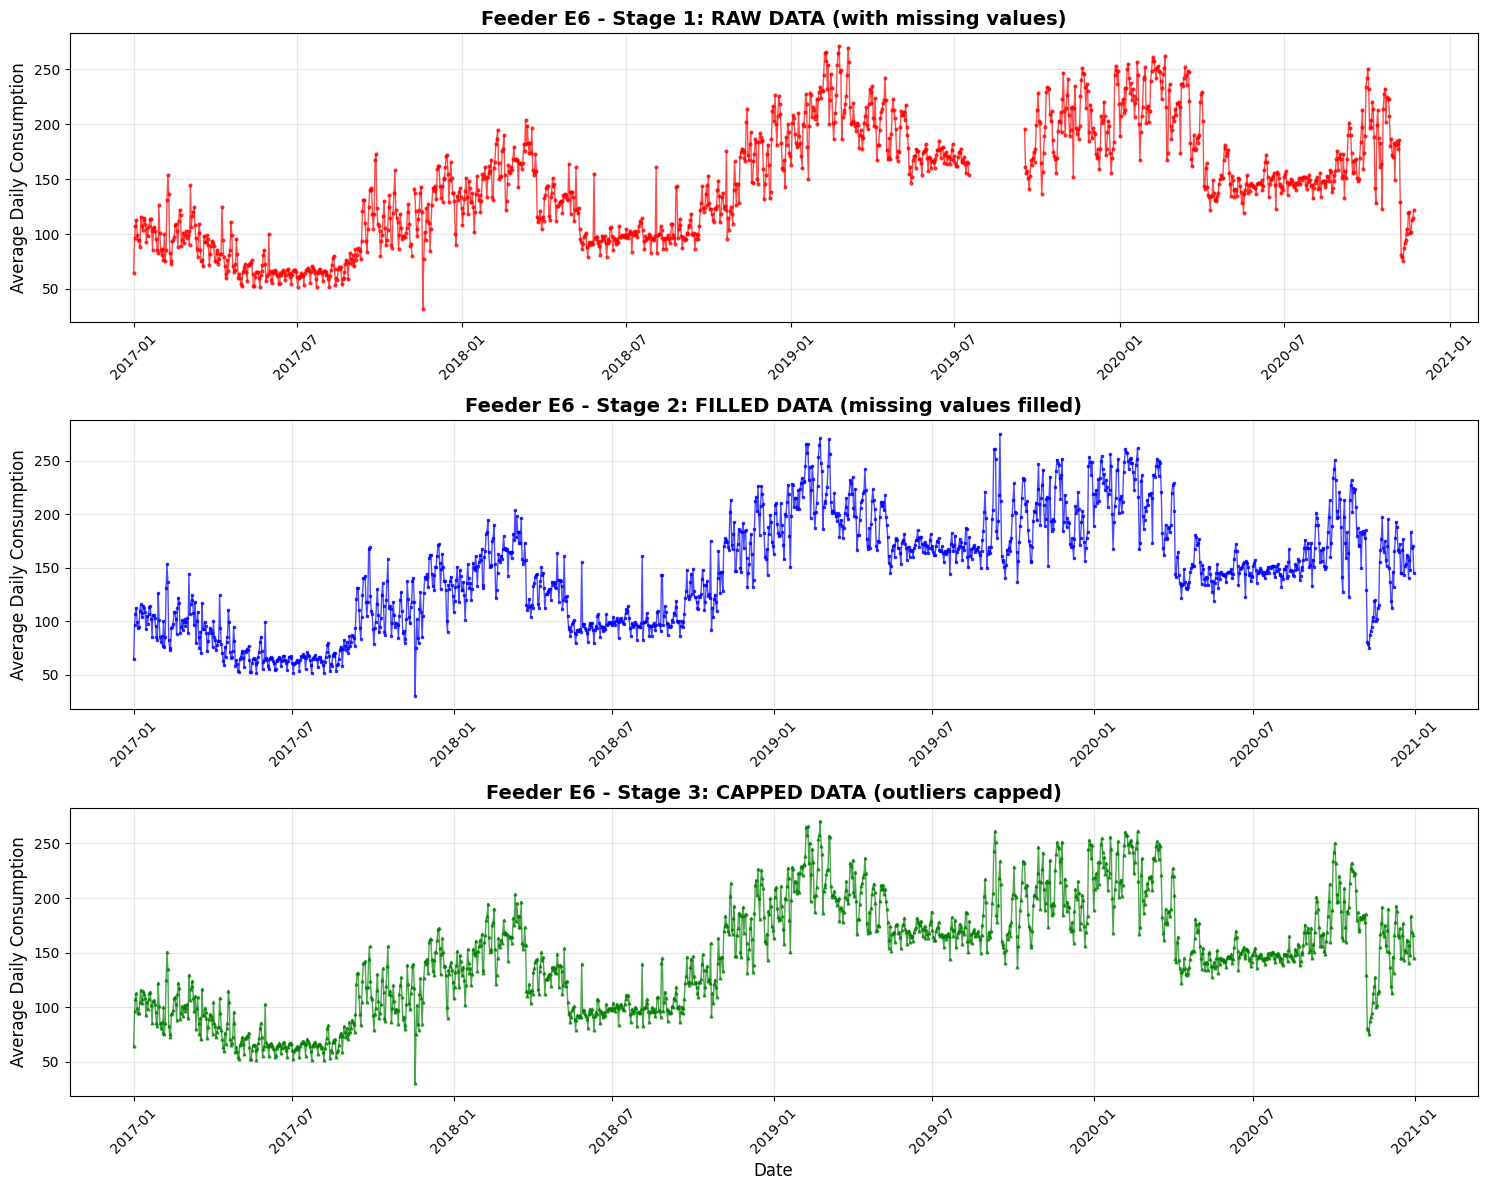

In [33]:
# Create three-panel comparison plot
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Raw data
axes[0].plot(df_E5_raw_daily.index, df_E5_raw_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, 
             color='red', alpha=0.7)
axes[0].set_title(f'Feeder {feeder} - Stage 1: RAW DATA (with missing values)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Daily Consumption', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: After filling missing values
axes[1].plot(df_E5_filled_daily.index, df_E5_filled_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, 
             color='blue', alpha=0.7)
axes[1].set_title(f'Feeder {feeder} - Stage 2: FILLED DATA (missing values filled)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Daily Consumption', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: After capping outliers
axes[2].plot(df_E5_capped_daily.index, df_E5_capped_daily.values, 
             marker='^', linestyle='-', markersize=2, linewidth=1, 
             color='green', alpha=0.7)
axes[2].set_title(f'Feeder {feeder} - Stage 3: CAPPED DATA (outliers capped)', 
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Average Daily Consumption', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print data range information
print(f"\nData Range Information for Feeder {feeder}:")
print("=" * 60)
print(f"Raw data: {df_E5_raw.index.min()} to {df_E5_raw.index.max()}")
print(f"Filled data: {df_E5_filled.index.min()} to {df_E5_filled.index.max()}")
print(f"Capped data: {df_E5_capped.index.min()} to {df_E5_capped.index.max()}")
print(f"\nTotal days in processed dataset: {len(df_E5_capped_daily)} days")
print(f"Expected days (2017-2020): {(pd.to_datetime('2021-01-01') - pd.to_datetime('2017-01-01')).days} days")

# Check if data extends to 2021-01-01
if df_E5_capped.index.max() >= pd.to_datetime('2021-01-01'):
    print("✓ Data extends through 2020-12-31 (up to 2021-01-01)")
else:
    print(f"⚠ Data ends at {df_E5_capped.index.max()}, not reaching 2021-01-01")

## Outlier Statistics Analysis

In [82]:
# Calculate outlier statistics for each feeder
# We'll detect outliers by comparing filled vs capped data

def detect_outliers_per_feeder(df_filled, df_capped):
    """
    Calculate outlier statistics for each feeder by comparing filled and capped data.
    Returns a DataFrame with outlier counts and percentages per feeder.
    """
    outlier_stats = []
    
    feeders = df_filled['feeder'].unique()
    
    for feeder in feeders:
        # Get filled and capped data for this feeder
        df_fill_feeder = df_filled[df_filled['feeder'] == feeder].copy()
        df_cap_feeder = df_capped[df_capped['feeder'] == feeder].copy()
        
        # Ensure datetime is in correct format and sort
        df_fill_feeder['datetime'] = pd.to_datetime(df_fill_feeder['datetime'])
        df_cap_feeder['datetime'] = pd.to_datetime(df_cap_feeder['datetime'])
        
        df_fill_feeder = df_fill_feeder.sort_values('datetime').reset_index(drop=True)
        df_cap_feeder = df_cap_feeder.sort_values('datetime').reset_index(drop=True)
        
        # Count outliers (values that were changed by capping)
        outliers_mask = df_fill_feeder['consumption'] != df_cap_feeder['consumption']
        n_outliers = outliers_mask.sum()
        total_points = len(df_fill_feeder)
        outlier_pct = (n_outliers / total_points) * 100 if total_points > 0 else 0
        
        outlier_stats.append({
            'feeder': feeder,
            'total_points': total_points,
            'outliers_found': n_outliers,
            'outlier_percentage': outlier_pct
        })
    
    return pd.DataFrame(outlier_stats)

# Calculate outlier statistics
outlier_stats_df = detect_outliers_per_feeder(df_filled, df_capped)

# Sort by number of outliers
outlier_stats_df_sorted = outlier_stats_df.sort_values('outliers_found', ascending=False)

# Display summary
print("=" * 80)
print("OUTLIER STATISTICS SUMMARY")
print("=" * 80)
print(f"\nTotal outliers found across all feeders: {outlier_stats_df['outliers_found'].sum():,}")
print(f"Total data points across all feeders: {outlier_stats_df['total_points'].sum():,}")
print(f"Overall outlier percentage: {(outlier_stats_df['outliers_found'].sum() / outlier_stats_df['total_points'].sum() * 100):.2f}%")

print("\n" + "=" * 80)
print("FEEDER WITH MOST OUTLIERS:")
print("=" * 80)
most_outliers = outlier_stats_df_sorted.iloc[0]
print(f"Feeder: {most_outliers['feeder']}")
print(f"Outliers found: {most_outliers['outliers_found']:,}")
print(f"Total points: {most_outliers['total_points']:,}")
print(f"Outlier percentage: {most_outliers['outlier_percentage']:.2f}%")

print("\n" + "=" * 80)
print("FEEDER WITH LEAST OUTLIERS:")
print("=" * 80)
least_outliers = outlier_stats_df_sorted.iloc[-1]
print(f"Feeder: {least_outliers['feeder']}")
print(f"Outliers found: {least_outliers['outliers_found']:,}")
print(f"Total points: {least_outliers['total_points']:,}")
print(f"Outlier percentage: {least_outliers['outlier_percentage']:.2f}%")

print("\n" + "=" * 80)
print("ALL FEEDERS (sorted by number of outliers):")
print("=" * 80)
print(outlier_stats_df_sorted.to_string(index=False))

OUTLIER STATISTICS SUMMARY

Total outliers found across all feeders: 26,007
Total data points across all feeders: 1,928,465
Overall outlier percentage: 1.35%

FEEDER WITH MOST OUTLIERS:
Feeder: A2
Outliers found: 1,305
Total points: 35,063
Outlier percentage: 3.72%

FEEDER WITH LEAST OUTLIERS:
Feeder: B3
Outliers found: 20
Total points: 35,063
Outlier percentage: 0.06%

ALL FEEDERS (sorted by number of outliers):
feeder  total_points  outliers_found  outlier_percentage
    A2         35063            1305              3.7219
    B5         35063            1058              3.0174
    E1         35063             945              2.6951
    M5         35063             914              2.6067
    A1         35063             885              2.5240
    M2         35063             872              2.4870
    J1         35063             855              2.4385
    C1         35063             819              2.3358
    F2         35063             771              2.1989
    M6       

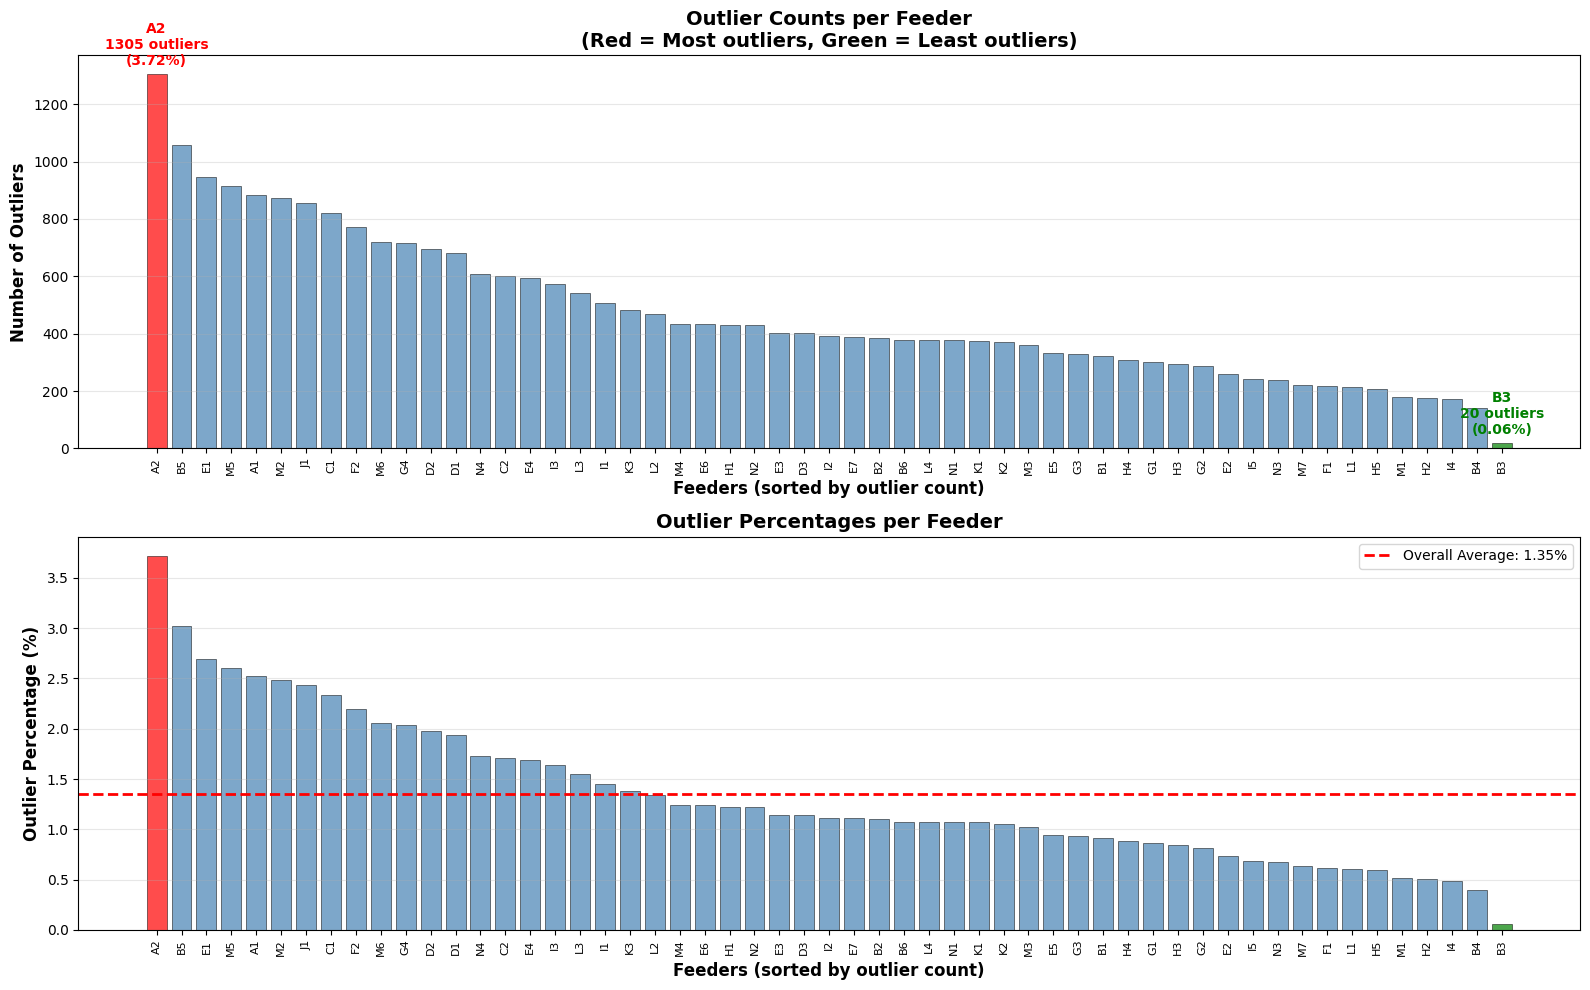


SUMMARY STATISTICS
Mean outliers per feeder: 472.9
Median outliers per feeder: 392.0
Std dev of outliers: 261.8

Mean outlier percentage: 1.35%
Median outlier percentage: 1.12%
Std dev of outlier percentage: 0.75%


In [83]:
# Visualize outlier statistics
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Bar chart of outlier counts per feeder
ax1 = axes[0]
colors = ['red' if feeder == outlier_stats_df_sorted.iloc[0]['feeder'] 
          else 'green' if feeder == outlier_stats_df_sorted.iloc[-1]['feeder']
          else 'steelblue' 
          for feeder in outlier_stats_df_sorted['feeder']]

bars = ax1.bar(range(len(outlier_stats_df_sorted)), 
               outlier_stats_df_sorted['outliers_found'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Feeders (sorted by outlier count)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Outliers', fontsize=12, fontweight='bold')
ax1.set_title('Outlier Counts per Feeder\n(Red = Most outliers, Green = Least outliers)', 
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(len(outlier_stats_df_sorted)))
ax1.set_xticklabels(outlier_stats_df_sorted['feeder'], rotation=90, fontsize=8)

# Add value labels on top bars with most and least outliers
max_idx = 0
min_idx = len(outlier_stats_df_sorted) - 1
ax1.text(max_idx, outlier_stats_df_sorted.iloc[max_idx]['outliers_found'] + 20,
         f"{outlier_stats_df_sorted.iloc[max_idx]['feeder']}\n{outlier_stats_df_sorted.iloc[max_idx]['outliers_found']} outliers\n({outlier_stats_df_sorted.iloc[max_idx]['outlier_percentage']:.2f}%)",
         ha='center', va='bottom', fontweight='bold', fontsize=10, color='red')
ax1.text(min_idx, outlier_stats_df_sorted.iloc[min_idx]['outliers_found'] + 20,
         f"{outlier_stats_df_sorted.iloc[min_idx]['feeder']}\n{outlier_stats_df_sorted.iloc[min_idx]['outliers_found']} outliers\n({outlier_stats_df_sorted.iloc[min_idx]['outlier_percentage']:.2f}%)",
         ha='center', va='bottom', fontweight='bold', fontsize=10, color='green')

# Plot 2: Bar chart of outlier percentages
ax2 = axes[1]
bars2 = ax2.bar(range(len(outlier_stats_df_sorted)), 
                outlier_stats_df_sorted['outlier_percentage'],
                color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Feeders (sorted by outlier count)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Outlier Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Outlier Percentages per Feeder', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(len(outlier_stats_df_sorted)))
ax2.set_xticklabels(outlier_stats_df_sorted['feeder'], rotation=90, fontsize=8)

# Add horizontal line for overall average
overall_pct = (outlier_stats_df['outliers_found'].sum() / outlier_stats_df['total_points'].sum() * 100)
ax2.axhline(y=overall_pct, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Average: {overall_pct:.2f}%')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"Mean outliers per feeder: {outlier_stats_df['outliers_found'].mean():.1f}")
print(f"Median outliers per feeder: {outlier_stats_df['outliers_found'].median():.1f}")
print(f"Std dev of outliers: {outlier_stats_df['outliers_found'].std():.1f}")
print(f"\nMean outlier percentage: {outlier_stats_df['outlier_percentage'].mean():.2f}%")
print(f"Median outlier percentage: {outlier_stats_df['outlier_percentage'].median():.2f}%")
print(f"Std dev of outlier percentage: {outlier_stats_df['outlier_percentage'].std():.2f}%")

## Comparison: Before and After (Overlayed)

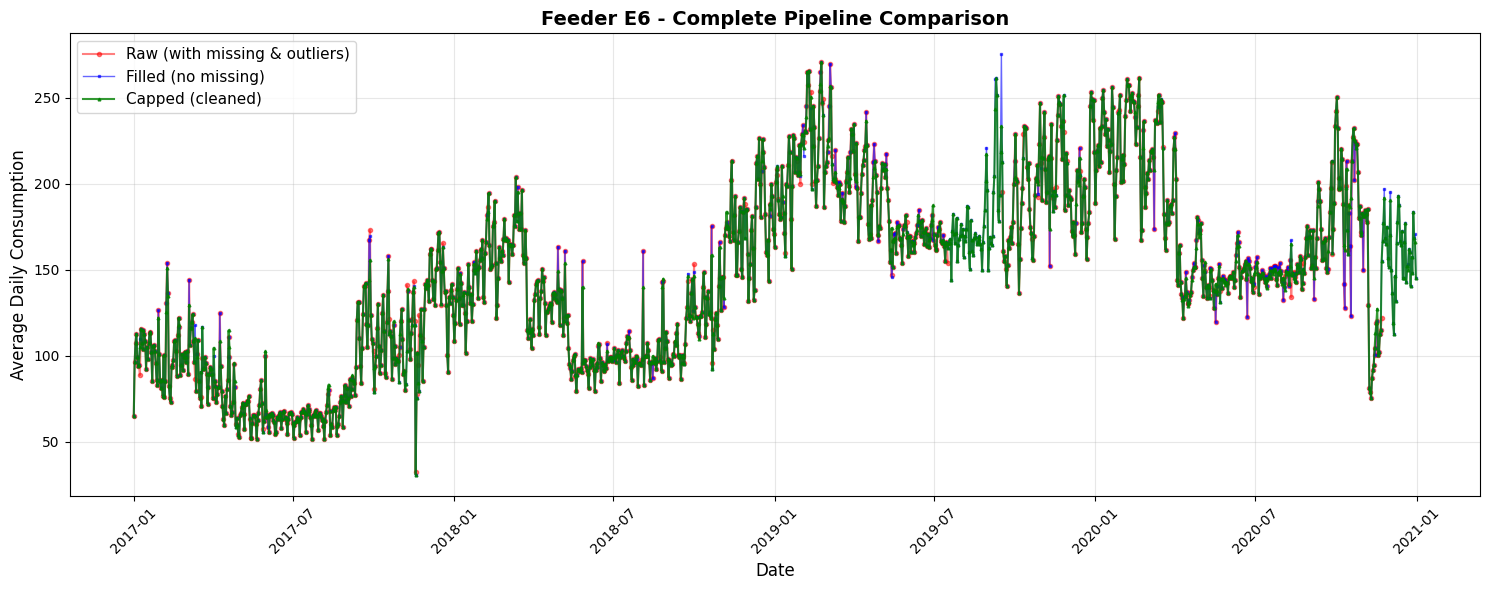

In [53]:
# Create overlay comparison
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

ax.plot(df_E5_raw_daily.index, df_E5_raw_daily.values, 
        marker='o', linestyle='-', markersize=3, linewidth=1.5, 
        color='red', alpha=0.5, label='Raw (with missing & outliers)')

ax.plot(df_E5_filled_daily.index, df_E5_filled_daily.values, 
        marker='s', linestyle='-', markersize=2, linewidth=1, 
        color='blue', alpha=0.6, label='Filled (no missing)')

ax.plot(df_E5_capped_daily.index, df_E5_capped_daily.values, 
        marker='^', linestyle='-', markersize=2, linewidth=1.5, 
        color='green', alpha=0.8, label='Capped (cleaned)')

ax.set_title(f'Feeder {feeder} - Complete Pipeline Comparison', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Daily Consumption', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Save Processed Data

## Final Correlation Matrix (After Pipeline)

Let's visualize how the correlation structure changed after filling missing values and capping outliers.

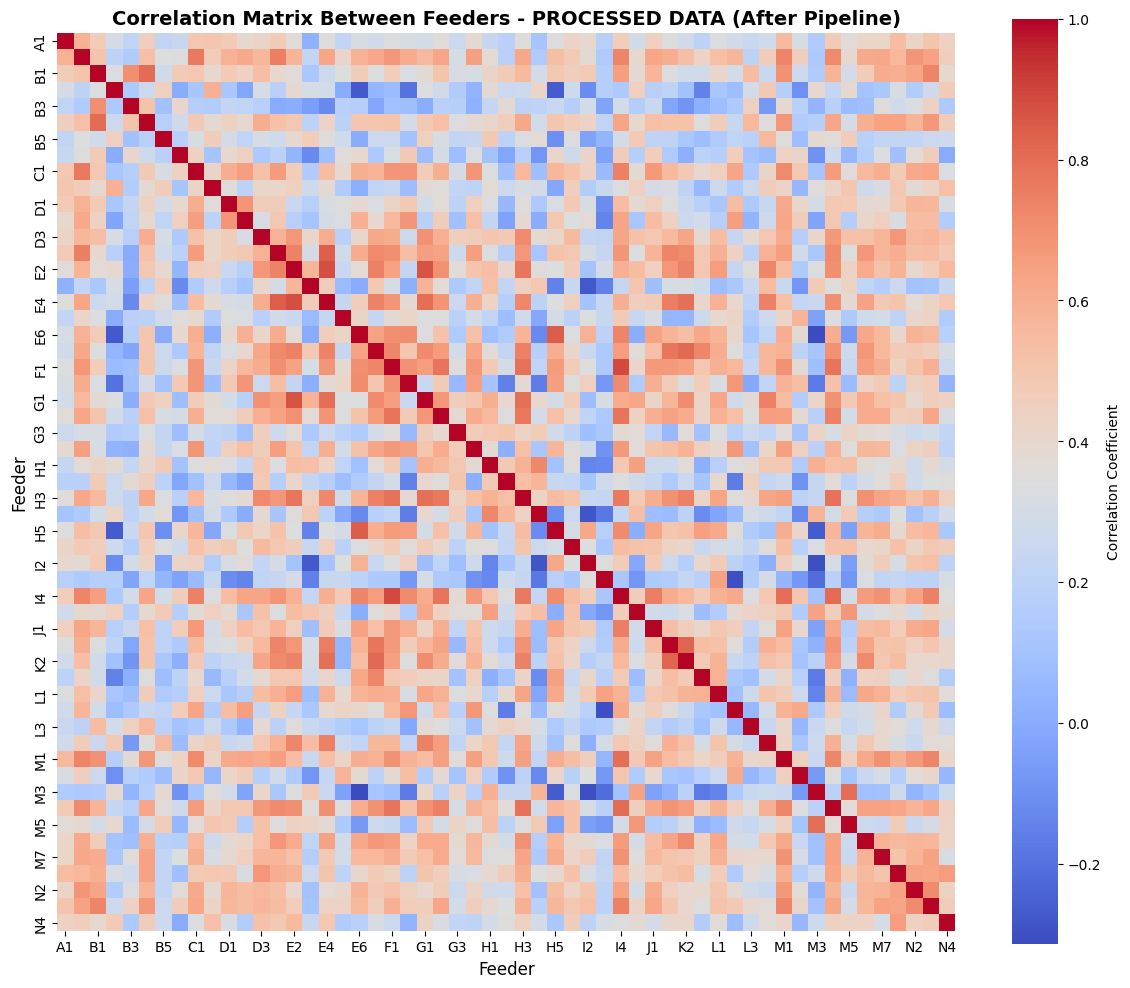

Average correlation (excluding diagonal): 0.370


In [40]:
# Create correlation matrix for processed data
pivot_df_capped = df_capped.pivot_table(index='datetime', columns='feeder', values='consumption')

# Compute the correlation matrix between feeders
corr_matrix_capped = pivot_df_capped.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_capped, annot=False, cmap='coolwarm', fmt='.2f', square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix Between Feeders - PROCESSED DATA (After Pipeline)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feeder', fontsize=12)
plt.ylabel('Feeder', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Average correlation (excluding diagonal): {corr_matrix_capped.values[~np.eye(corr_matrix_capped.shape[0], dtype=bool)].mean():.3f}")

## Correlation Matrix Comparison

Compare the correlation changes between raw and processed data.

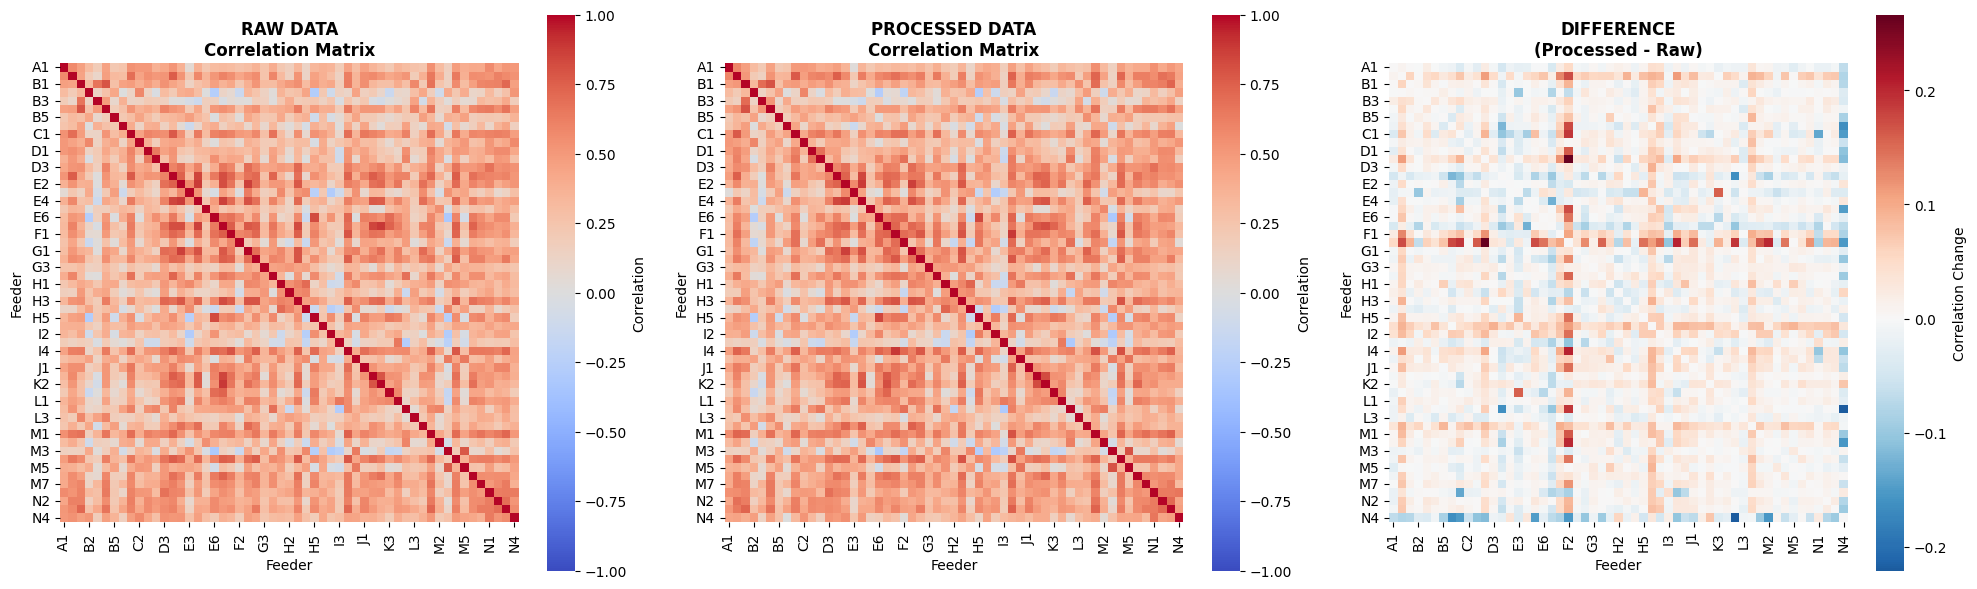

Correlation Summary:
Raw data - Average correlation: 0.362
Raw data - Std correlation: 0.206

Processed data - Average correlation: 0.370
Processed data - Std correlation: 0.212

Average absolute change: 0.027
Max increase: 0.266
Max decrease: -0.221


In [41]:
# Calculate the difference in correlations
corr_diff = corr_matrix_capped - corr_matrix_raw

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Raw correlation
sns.heatmap(corr_matrix_raw, annot=False, cmap='coolwarm', fmt='.2f', square=True, 
            ax=axes[0], vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
axes[0].set_title('RAW DATA\nCorrelation Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feeder')
axes[0].set_ylabel('Feeder')

# Plot 2: Processed correlation
sns.heatmap(corr_matrix_capped, annot=False, cmap='coolwarm', fmt='.2f', square=True, 
            ax=axes[1], vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
axes[1].set_title('PROCESSED DATA\nCorrelation Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feeder')
axes[1].set_ylabel('Feeder')

# Plot 3: Difference
sns.heatmap(corr_diff, annot=False, cmap='RdBu_r', fmt='.2f', square=True, 
            ax=axes[2], center=0, cbar_kws={'label': 'Correlation Change'})
axes[2].set_title('DIFFERENCE\n(Processed - Raw)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Feeder')
axes[2].set_ylabel('Feeder')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Correlation Summary:")
print("=" * 60)
print(f"Raw data - Average correlation: {corr_matrix_raw.values[~np.eye(corr_matrix_raw.shape[0], dtype=bool)].mean():.3f}")
print(f"Raw data - Std correlation: {corr_matrix_raw.values[~np.eye(corr_matrix_raw.shape[0], dtype=bool)].std():.3f}")
print()
print(f"Processed data - Average correlation: {corr_matrix_capped.values[~np.eye(corr_matrix_capped.shape[0], dtype=bool)].mean():.3f}")
print(f"Processed data - Std correlation: {corr_matrix_capped.values[~np.eye(corr_matrix_capped.shape[0], dtype=bool)].std():.3f}")
print()
print(f"Average absolute change: {np.abs(corr_diff.values[~np.eye(corr_diff.shape[0], dtype=bool)]).mean():.3f}")
print(f"Max increase: {corr_diff.values[~np.eye(corr_diff.shape[0], dtype=bool)].max():.3f}")
print(f"Max decrease: {corr_diff.values[~np.eye(corr_diff.shape[0], dtype=bool)].min():.3f}")